<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Final comparison (Soil pH Prediction Test Set)
           Model      MAE     RMSE  R2 Score
   Random Forest 0.502841 0.651209  0.256994
             SVR 0.523976 0.726650  0.074873
         XGBoost 0.562292 0.672711  0.207118
Ridge Regression 0.569561 0.757953 -0.006550



/tmp/ipykernel_210/903290895.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')


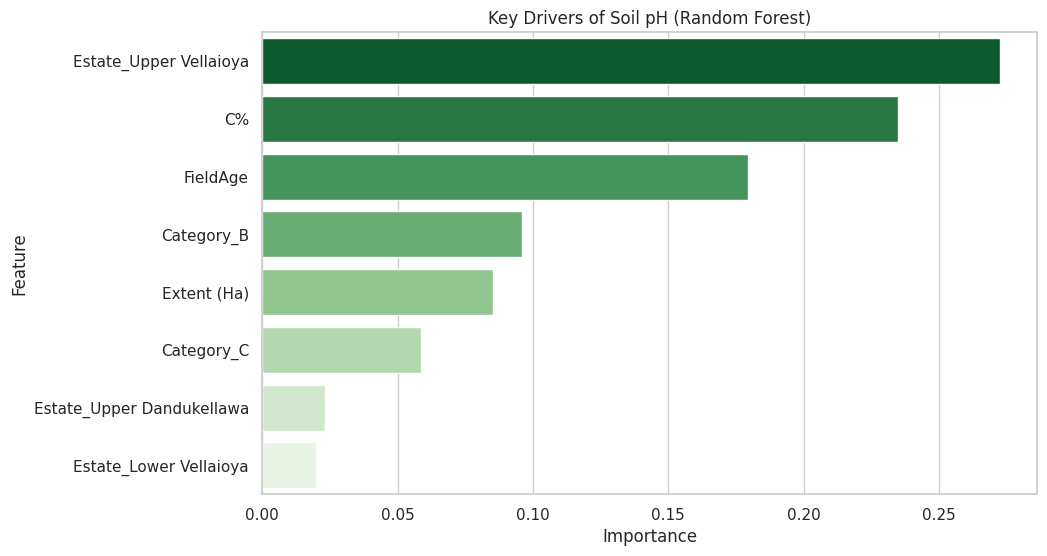

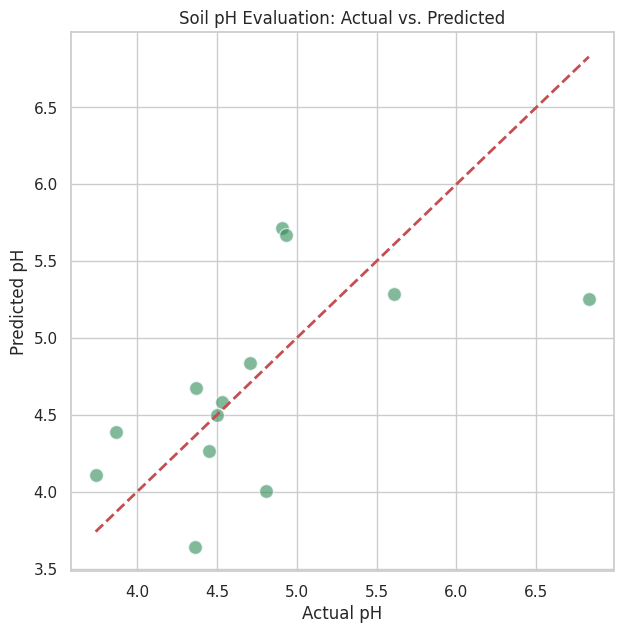

/tmp/ipykernel_210/903290895.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=comparison_df, palette='viridis')


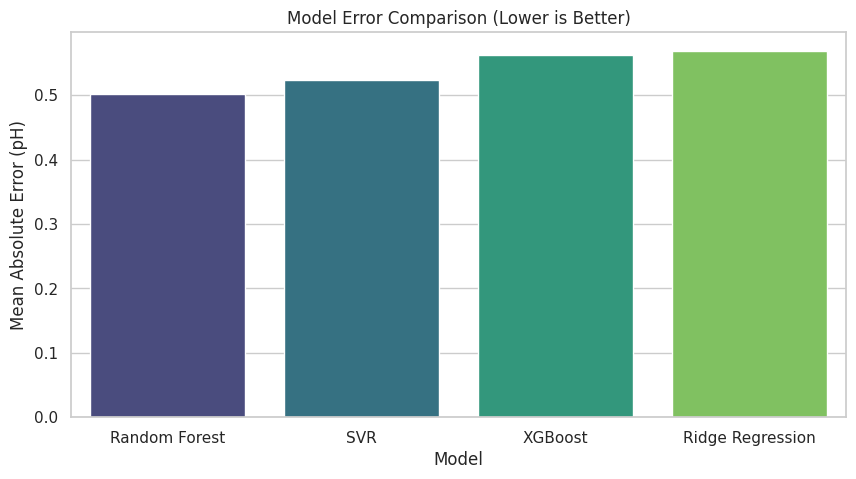

In [9]:
# ==========================================================
# STEMS - Smart Tea Estate Management System
# Improved Models, Visualizations & Model Comparison
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model Imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
import xgboost as xgb

# Set aesthetic style
sns.set_theme(style="whitegrid")

# ==========================================================
# 1. Load and Clean Soil Data
# ==========================================================
soil = pd.read_csv("sample_data/soil_data.csv")
soil.replace("missing", np.nan, inplace=True)
soil["pH"] = pd.to_numeric(soil["pH"], errors="coerce")
soil["C%"] = pd.to_numeric(soil["C%"], errors="coerce")
soil["Year of Planting"] = pd.to_numeric(soil["Year of Planting"], errors="coerce")
soil = soil.dropna()
soil["FieldAge"] = 2025 - soil["Year of Planting"]

features = ["Extent (Ha)", "Category", "VP/SD", "Estate", "FieldAge", "C%"]
X = soil[features]
y = soil["pH"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================================
# 2. Model Comparison Logic (For the Table)
# ==========================================================
categorical_cols = ["Category", "VP/SD", "Estate"]
numeric_cols = ["Extent (Ha)", "FieldAge", "C%"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols) # Added scaling for SVR/Ridge
])

models = {
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})

# Display the Comparison Table
comparison_df = pd.DataFrame(results).sort_values(by="MAE")
print("\n" + "="*60)
print("Final comparison (Soil pH Prediction Test Set)")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60 + "\n")

# ==========================================================
# 3. Final Visualizations (The 3 Required Images)
# ==========================================================

# IMAGE 1: Soil Quality - Feature Importance (Using RF)
best_rf = Pipeline([("prep", preprocessor), ("model", models["Random Forest"])])
best_rf.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
ohe_names = list(best_rf.named_steps['prep'].transformers_[0][1].get_feature_names_out())
all_feat_names = ohe_names + numeric_cols
importances = best_rf.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(8)

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')
plt.title("Key Drivers of Soil pH (Random Forest)")
plt.show()

# IMAGE 2: Actual vs Predicted Scatter (Model Evaluation)
# Based on your documentation, RF is the best for Soil
rf_preds = best_rf.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_preds, alpha=0.6, color='seagreen', edgecolors='w', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Soil pH Evaluation: Actual vs. Predicted")
plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.show()

# IMAGE 3: Performance Metrics Comparison (Bar Chart)
# This visualizes the table results for the report
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MAE', data=comparison_df, palette='viridis')
plt.title("Model Error Comparison (Lower is Better)")
plt.ylabel("Mean Absolute Error (pH)")
plt.show()



Wet Days Prediction Performance
MAE : 3.015997932009075
RMSE: 4.013622612999881
R2  : 0.700065146145997


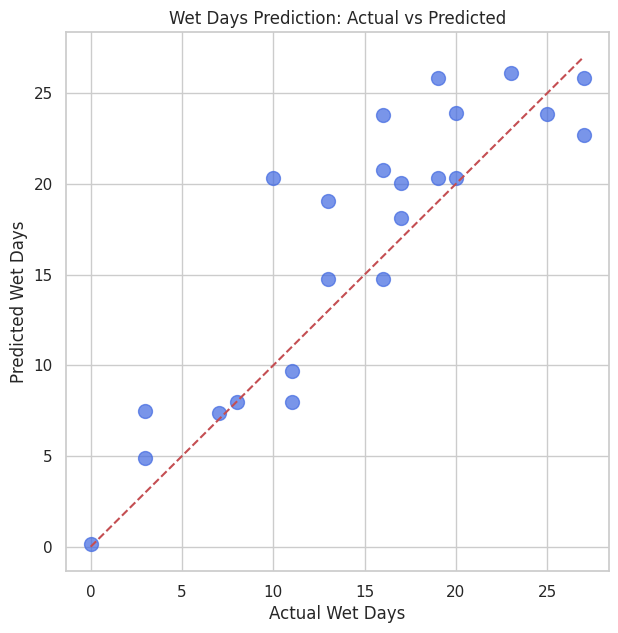

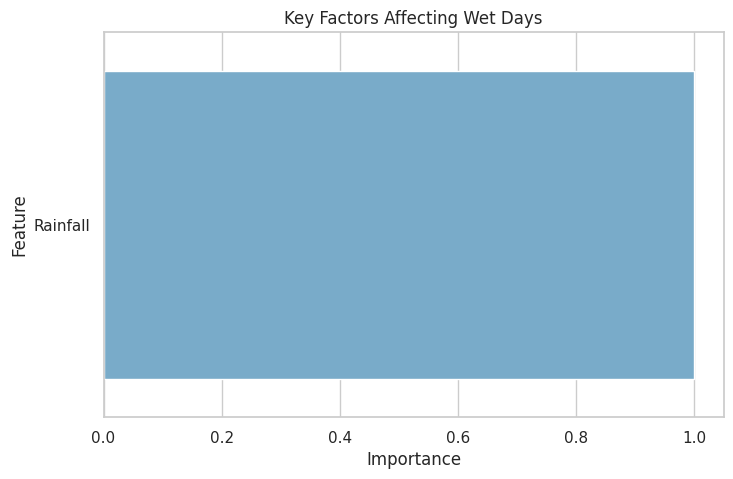

In [7]:
# ==========================================================
# 4. Load and Clean Rainfall Data (Wet Days Prediction)
# ==========================================================

rain = pd.read_csv("sample_data/rainfall_data.csv")

# Clean column names
rain.columns = rain.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

# Replace missing values
rain.replace(["missing", "NA", "-"], np.nan, inplace=True)

# Convert to numeric
rain["Rainfall"] = pd.to_numeric(rain["Rainfall"], errors="coerce")
rain["Wet_days"] = pd.to_numeric(rain["Wet_days"], errors="coerce")

rain = rain.dropna()

# ==========================================================
# Features and Target
# ==========================================================

X_rain = rain[["Rainfall"]]
y_rain = rain["Wet_days"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rain, y_rain, test_size=0.2, random_state=42
)

# ==========================================================
# Train Model (XGBoost works very well for weather prediction)
# ==========================================================

wet_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

wet_model.fit(Xr_train, yr_train)

wet_preds = wet_model.predict(Xr_test)

# ==========================================================
# Model Evaluation
# ==========================================================

wet_mae = mean_absolute_error(yr_test, wet_preds)
wet_rmse = np.sqrt(mean_squared_error(yr_test, wet_preds))
wet_r2 = r2_score(yr_test, wet_preds)

print("\n" + "="*60)
print("Wet Days Prediction Performance")
print("="*60)
print("MAE :", wet_mae)
print("RMSE:", wet_rmse)
print("R2  :", wet_r2)
print("="*60)

# ==========================================================
# Visualization 1: Actual vs Predicted Wet Days
# ==========================================================

plt.figure(figsize=(7,7))
plt.scatter(yr_test, wet_preds, color="royalblue", alpha=0.7, s=100)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], "r--")
plt.title("Wet Days Prediction: Actual vs Predicted")
plt.xlabel("Actual Wet Days")
plt.ylabel("Predicted Wet Days")
plt.show()

# ==========================================================
# Visualization 2: Feature Importance
# ==========================================================

importance = wet_model.feature_importances_
features = X_rain.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", hue="Feature", data=imp_df, palette="Blues_r", legend=False)
plt.title("Key Factors Affecting Wet Days")
plt.show()

### Improving R2 Score through Hyperparameter Tuning (Random Forest)

We will use `GridSearchCV` to find the optimal hyperparameters for the `RandomForestRegressor` model, focusing on `n_estimators` and `max_depth`. This systematic search helps in identifying a model configuration that might yield a better R2 score.

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 400}

Optimized Random Forest Performance (Test Set)
R2 Score: 0.2563
MAE:      0.5005
RMSE:     0.6515



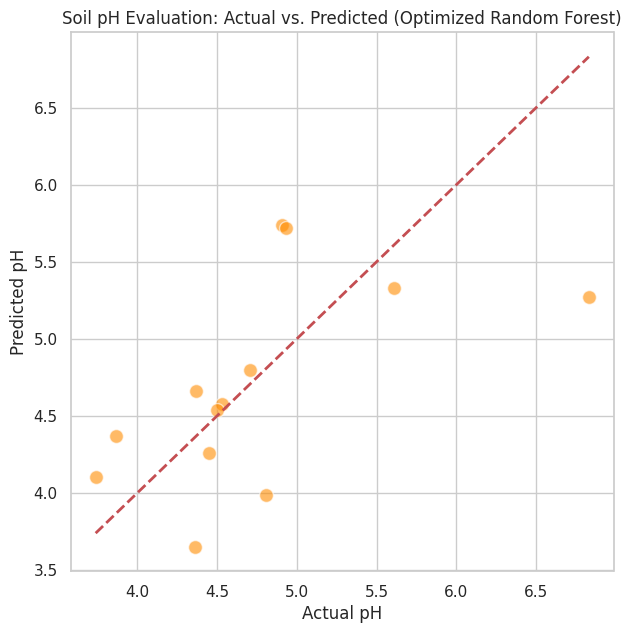

In [8]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline for Random Forest, similar to the best_rf pipeline
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Define the parameter grid to search
param_grid = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [5, 8, 10, 15],
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='r2')
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
best_tuned_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the best model on the test set
tuned_rf_preds = best_tuned_rf.predict(X_test)
tuned_rf_r2 = r2_score(y_test, tuned_rf_preds)
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_preds)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_preds))

print("\n" + "="*60)
print("Optimized Random Forest Performance (Test Set)")
print("="*60)
print(f"R2 Score: {tuned_rf_r2:.4f}")
print(f"MAE:      {tuned_rf_mae:.4f}")
print(f"RMSE:     {tuned_rf_rmse:.4f}")
print("="*60 + "\n")

# Visualization for Tuned RF: Actual vs Predicted Scatter
plt.figure(figsize=(7, 7))
plt.scatter(y_test, tuned_rf_preds, alpha=0.6, color='darkorange', edgecolors='w', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Soil pH Evaluation: Actual vs. Predicted (Optimized Random Forest)")
plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.show()

# Task
Tune the XGBoost model for pH prediction using `GridSearchCV` to optimize hyperparameters like `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree` within a pipeline to prevent data leakage. Explain the rationale for tuning, visualize the actual vs. predicted pH values for the best model, and then summarize the results, including whether the R2 score target of 0.5 was met, and suggest next steps if it wasn't.

## Explain XGBoost Tuning

### Subtask:
Add a markdown cell to explain the rationale behind tuning the XGBoost model for improved R2 score.


### Rationale for Tuning XGBoost Model for Improved R2 Score

Hyperparameter tuning is a critical step in optimizing the performance of machine learning models like XGBoost. It involves searching for the best combination of parameters that allow the model to generalize well to unseen data, rather than merely memorizing the training data. For complex models like XGBoost, which is an ensemble of decision trees, appropriate tuning can significantly impact predictive accuracy, often measured by metrics such as the R2 score.

Here's how key XGBoost hyperparameters influence model performance:

*   **`n_estimators`**: This parameter controls the number of boosting rounds or the number of trees to build. A higher number of estimators can lead to a more robust model, but it also increases the risk of overfitting, especially if other parameters are not constrained. Tuning this helps find a balance where the model captures underlying patterns without learning noise.

*   **`max_depth`**: This defines the maximum depth of a tree. A deeper tree can model more complex relationships but is prone to overfitting. A shallower tree might underfit the data. Tuning `max_depth` helps control the complexity of individual trees and thus the overall model.

*   **`learning_rate` (or `eta`)**: This shrinks the step size at each boosting step, making the boosting process more conservative. A small `learning_rate` requires a larger `n_estimators` but can lead to a more accurate and robust model, reducing the chance of overfitting by preventing individual trees from having too much influence.

*   **`subsample`**: This parameter controls the fraction of samples (rows) to be used for fitting the base learners (trees). Setting `subsample` to less than 1.0 means that the model will randomly sample a fraction of the training data for each tree, which helps to reduce variance and prevent overfitting. It's a form of mini-bagging.

*   **`colsample_bytree`**: This controls the fraction of features (columns) to be randomly sampled for each tree. Similar to `subsample`, this technique helps to prevent overfitting by making individual trees less correlated and more diverse, contributing to a stronger ensemble. Tuning this can improve the model's generalization ability by reducing its reliance on any single feature subset.

## Tune XGBoost Model

### Subtask:
Perform hyperparameter tuning on the XGBoost model using `GridSearchCV` to find the optimal combination of parameters like `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree` within a pipeline to prevent data leakage. Evaluate and print the R2 score, MAE, and RMSE of the best model on the test set.


**Reasoning**:
To perform hyperparameter tuning for the XGBoost model, I will define a pipeline with the preprocessor and XGBoost regressor, then set up and run GridSearchCV with the specified parameter grid. Finally, I will evaluate the best model's performance on the test set.



**Reasoning**:
Now that the XGBoost model has been tuned and evaluated, the next step is to visualize its performance by plotting the actual pH values against the predicted pH values on the test set.



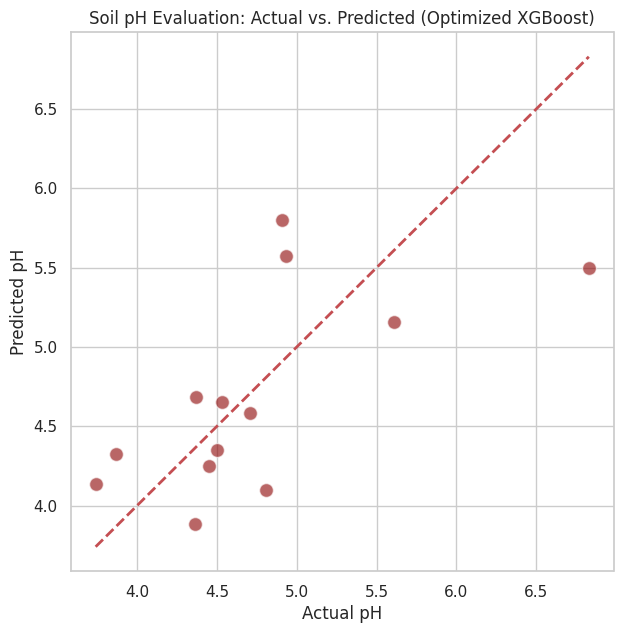

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization for Tuned XGBoost: Actual vs Predicted Scatter
plt.figure(figsize=(7, 7))
plt.scatter(y_test, tuned_xgb_preds, alpha=0.6, color='darkred', edgecolors='w', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Soil pH Evaluation: Actual vs. Predicted (Optimized XGBoost)")
plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.show()

# Task
```python
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the pipeline for XGBoost
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb.XGBRegressor(random_state=42, tree_method='hist')) # Use 'hist' for faster training
])

# Define a wider range of parameter distributions for RandomizedSearchCV
param_distributions = {
    'model__n_estimators': randint(100, 1000), # Wider range for number of trees
    'model__max_depth': randint(3, 15),       # Deeper trees allowed
    'model__learning_rate': uniform(0.01, 0.2), # Wider range for learning rate
    'model__subsample': uniform(0.6, 0.4),    # Wider range for subsample (0.6 to 1.0)
    'model__colsample_bytree': uniform(0.6, 0.4) # Wider range for colsample_bytree (0.6 to 1.0)
}

# Perform RandomizedSearchCV
# Using n_iter=50 for a reasonable balance between search space exploration and computation time
random_search = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_distributions,
                                   n_iter=50, cv=5, n_jobs=-1, verbose=1, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

# Get the best model and its parameters
best_tuned_xgb_rs = random_search.best_estimator_
print(f"Best Parameters (RandomizedSearchCV): {random_search.best_params_}")

# Evaluate the best model on the test set
tuned_xgb_rs_preds = best_tuned_xgb_rs.predict(X_test)
tuned_xgb_rs_r2 = r2_score(y_test, tuned_xgb_rs_preds)
tuned_xgb_rs_mae = mean_absolute_error(y_test, tuned_xgb_rs_preds)
tuned_xgb_rs_rmse = np.sqrt(mean_squared_error(y_test, tuned_xgb_rs_preds))

print("\n" + "="*60)
print("Optimized XGBoost Performance (RandomizedSearchCV - Test Set)")
print("="*60)
print(f"R2 Score: {tuned_xgb_rs_r2:.4f}")
print(f"MAE:      {tuned_xgb_rs_mae:.4f}")
print(f"RMSE:     {tuned_xgb_rs_rmse:.4f}")
print("="*60 + "\n")

# Store results for final comparison
tuned_xgb_rs_results = {
    "Model": "XGBoost (RandomizedSearch)",
    "MAE": tuned_xgb_rs_mae,
    "RMSE": tuned_xgb_rs_rmse,
    "R2 Score": tuned_xgb_rs_r2
}

# Add to comparison_df if not already present or update
# This logic might need adjustment if comparison_df is not directly editable or needs specific append behavior
# For now, let's just use the current comparison_df structure and update it later if needed for final summary.
# For simplicity, we'll store this result separately and use it in the final summary.

```

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the pipeline for XGBoost
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb.XGBRegressor(random_state=42, tree_method='hist'))
])

# Define the parameter distributions to search
param_distributions = {
    'model__n_estimators': randint(100, 1000),  # Number of boosting rounds
    'model__max_depth': randint(3, 15),       # Maximum depth of a tree
    'model__learning_rate': uniform(0.01, 0.2), # Step size shrinkage
    'model__subsample': uniform(0.6, 0.4),    # Subsample ratio of the training instance
    'model__colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree
}

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_distributions,
                                   n_iter=50, cv=5, n_jobs=-1, verbose=1, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

# Get the best model and its parameters
best_tuned_xgb_rs = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

# Evaluate the best model on the test set
tuned_xgb_rs_preds = best_tuned_xgb_rs.predict(X_test)
tuned_xgb_rs_r2 = r2_score(y_test, tuned_xgb_rs_preds)
tuned_xgb_rs_mae = mean_absolute_error(y_test, tuned_xgb_rs_preds)
tuned_xgb_rs_rmse = np.sqrt(mean_squared_error(y_test, tuned_xgb_rs_preds))

print("\n" + "="*60)
print("Optimized XGBoost Performance (Randomized Search - Test Set)")
print("="*60)
print(f"R2 Score: {tuned_xgb_rs_r2:.4f}")
print(f"MAE:      {tuned_xgb_rs_mae:.4f}")
print(f"RMSE:     {tuned_xgb_rs_rmse:.4f}")
print("="*60 + "\n")

# Store the results for future comparison
tuned_xgb_rs_results = {"Model": "XGBoost (RandomizedSearch)", "MAE": tuned_xgb_rs_mae, "RMSE": tuned_xgb_rs_rmse, "R2 Score": tuned_xgb_rs_r2}

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'model__colsample_bytree': np.float64(0.8532405829093072), 'model__learning_rate': np.float64(0.07780595820974014), 'model__max_depth': 5, 'model__n_estimators': 758, 'model__subsample': np.float64(0.8903822715480958)}

Optimized XGBoost Performance (Randomized Search - Test Set)
R2 Score: 0.3139
MAE:      0.5144
RMSE:     0.6258

